In [10]:
import scanpy as sc

adata = sc.read('/data1/r20user3/shared_project/Hist2Cell/data/breast_sc/cell2location_res/her2st/sp.h5ad')
adata

AnnData object with n_obs × n_vars = 13620 × 9739
    obs: 'sample', '_indices', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'

In [15]:
adata.X

<13620x9739 sparse matrix of type '<class 'numpy.float32'>'
	with 25136734 stored elements in Compressed Sparse Row format>

In [7]:
from cell2location import run_colocation
import numpy as np


run_name = f'/data1/r20user3/shared_project/Hist2Cell/code/analysis/NMF/cross_source'

res_dict, adata_vis = run_colocation(
    adata, 
    model_name='CoLocatedGroupsSklearnNMF',
    train_args={
      'n_fact': np.arange(11, 13), # IMPORTANT: use a wider range of the number of factors (5-30)
      'sample_name_col': 'sample', # columns in adata_vis.obs that identifies sample           
      'n_restarts': 3 # number of training restarts
    },
    # the hyperparameters of NMF can be also adjusted:
    model_kwargs={'alpha': 0.01, 'init': 'random', "nmf_kwd_args": {"tol": 0.000001}},
    export_args={'path': f'{run_name}/CoLocatedComb/'}
) 

### Analysis name: CoLocatedGroupsSklearnNMF_11combinations_13620locations_39factors


/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/cell2location/models/base/base_model.py:149: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/cell2location/run_colocation.py:244: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value e

Some error in plotting with scanpy or `cell2location.plt.plot_factor_spatial()`
 No module named 'plotnine'
### Analysis name: CoLocatedGroupsSklearnNMF_12combinations_13620locations_39factors


/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/cell2location/models/base/base_model.py:149: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/cell2location/run_colocation.py:244: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value e

Some error in plotting with scanpy or `cell2location.plt.plot_factor_spatial()`
 No module named 'plotnine'


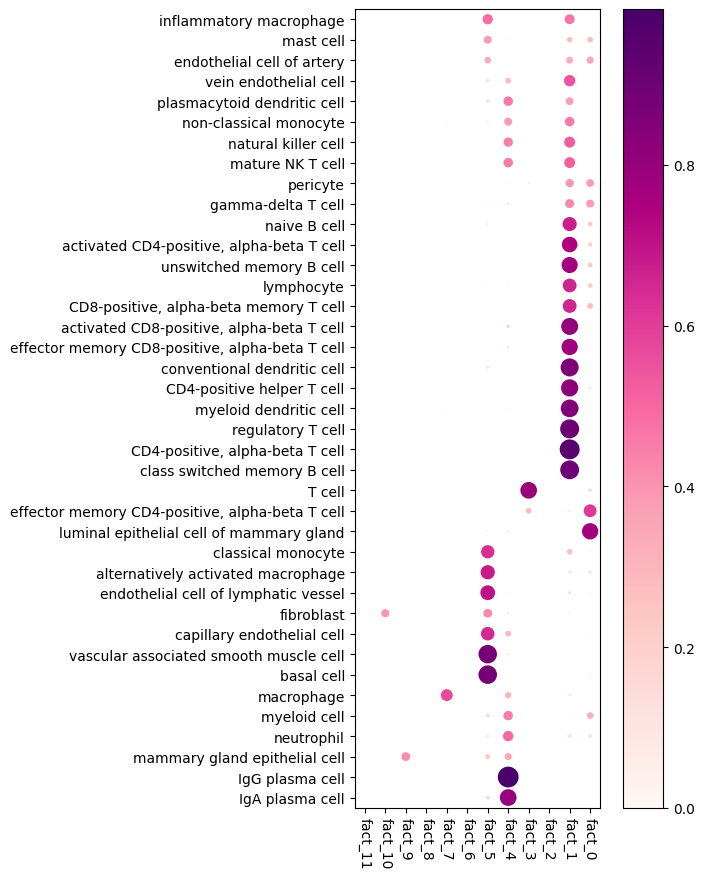

In [8]:
res_dict['n_fact12']['mod'].plot_cell_type_loadings()